# DiD Espacial — Ciclovía como Experimento Natural Recurrente

**Pregunta:** ¿La Ciclovía dominical (127 km de vías cerradas, 7am–2pm) reduce o aumenta la afluencia en estaciones adyacentes a sus rutas?

**Identificación:** La Ciclovía opera cada domingo por decisión del IDRD, independientemente de la demanda de TM. Las estaciones cercanas a rutas de Ciclovía reciben el 'tratamiento'; las estaciones lejanas son el control natural.

**Diseño principal — DiD espacial entre días:**
$$
\log(\text{total}_{it}) = \beta \cdot (\text{sunday}_t \times \text{cerca}_i) + \alpha_i + \delta_{\text{dow}} + \delta_{\text{month}} + \varepsilon_{it}
$$

**Diseño robusto — DiD dentro del domingo (ventana horaria):**
$$
\log(\text{total}_{iht}) = \beta \cdot (\text{cerca}_i \times \text{ventana}_h) + \alpha_i + \alpha_h + \varepsilon_{iht}
$$
donde $\text{ventana}_h = 1$ si $7 \le h < 14$ (horas activas de Ciclovía), en muestra restringida a domingos.

**Nota:** En 2025, enero 1 cae en miércoles → **los 52 domingos del año tienen Ciclovía.** La identificación proviene de la variación espacial (cerca vs. lejos) y temporal (dentro del domingo: antes vs. después de las 2pm).

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import datetime
import warnings
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from pathlib import Path

warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Clasificación espacial de estaciones

In [2]:
# Cargar resultados del spatial join (precalculado)
stations_tag = gpd.read_file(PROJ / 'data/external/stations_ciclovia_tag.geojson')

cerca_map = stations_tag.set_index('codigo_nodo_estacion')['cerca_ciclovia'].to_dict()
n_cerca = sum(v == 1 for v in cerca_map.values())
n_lejos = sum(v == 0 for v in cerca_map.values())

print(f"Estaciones TRATADAS (≤500m de ruta Ciclovía): {n_cerca}")
print(f"Estaciones CONTROL  (>500m de ruta Ciclovía): {n_lejos}")
print(f"Rutas Ciclovía: 15 tramos · 127.2 km totales")

Estaciones TRATADAS (≤500m de ruta Ciclovía): 63
Estaciones CONTROL  (>500m de ruta Ciclovía): 86
Rutas Ciclovía: 15 tramos · 127.2 km totales


ERROR 1: PROJ: proj_create_from_database: Open of /home/andre/miniconda3/envs/transmilenio-project/share/proj failed


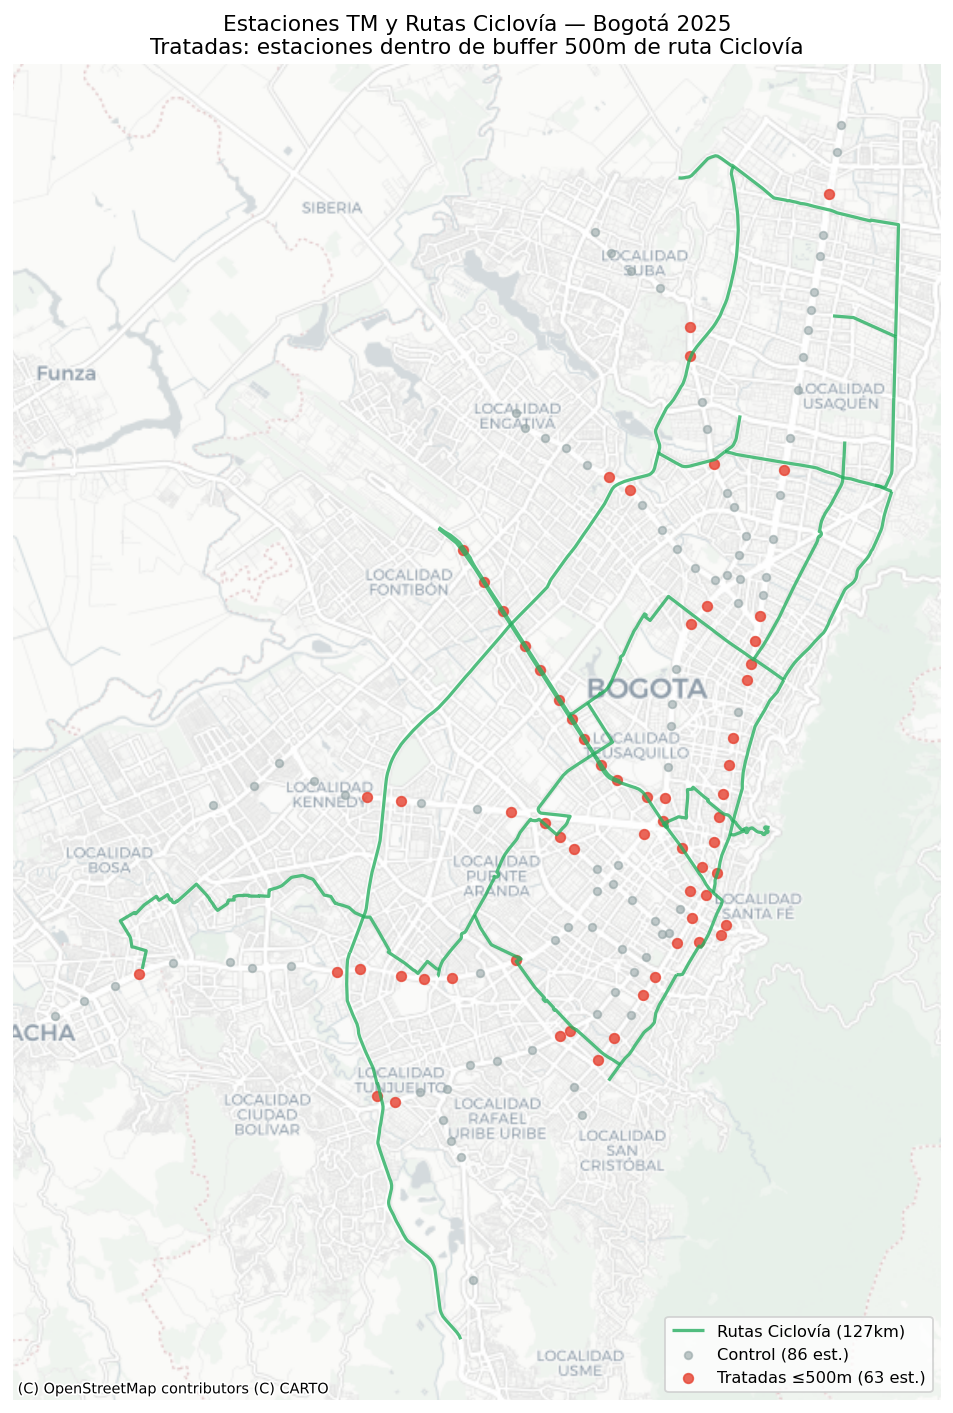

In [3]:
# Mapa de estaciones tratadas vs control sobre rutas Ciclovía
ciclovia = gpd.read_file(PROJ / 'data/external/ciclovia_bogota.geojson').to_crs('EPSG:4326')

# Convertir a Web Mercator para agregar basemap
ciclovia_wm = ciclovia.to_crs(epsg=3857)
treated_wm  = stations_tag[stations_tag.cerca_ciclovia == 1].to_crs(epsg=3857)
control_wm  = stations_tag[stations_tag.cerca_ciclovia == 0].to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 11))

ciclovia_wm.plot(ax=ax, color='#27ae60', linewidth=1.8, alpha=0.8, label='Rutas Ciclovía (127km)')
control_wm.plot(ax=ax, color='#95a5a6', markersize=18, alpha=0.6, label=f'Control ({n_lejos} est.)')
treated_wm.plot(ax=ax, color='#e74c3c',  markersize=28, alpha=0.85, label=f'Tratadas ≤500m ({n_cerca} est.)')

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()
ax.set_title("Estaciones TM y Rutas Ciclovía — Bogotá 2025\n"
             "Tratadas: estaciones dentro de buffer 500m de ruta Ciclovía",
             fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_mapa_tratamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Panel diario — todos los días

In [4]:
files = sorted(glob.glob(str(PROJ / 'data/processed/parquet/*.parquet')))
print(f"Cargando {len(files)} archivos...")

frames = []
for f in files:
    d = pd.read_parquet(f)
    agg = d.groupby(['fecha', 'codigo_estacion'])['total'].sum().reset_index()
    frames.append(agg)

panel = (
    pd.concat(frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
      .sort_values(['codigo_estacion', 'fecha'])
      .reset_index(drop=True)
)
panel = panel[panel.total > 0].copy()

# Añadir clasificación espacial
panel['cerca'] = panel.codigo_estacion.map(cerca_map).fillna(0).astype(int)

# Variables temporales
panel['dow']       = panel.fecha.dt.dayofweek   # 0=lunes, 6=domingo
panel['month']     = panel.fecha.dt.month
panel['is_sunday'] = (panel.dow == 6).astype(int)
panel['log_total'] = np.log(panel.total)

print(f"Panel: {len(panel):,.0f} obs · {panel.codigo_estacion.nunique()} est. · {panel.fecha.nunique()} días")
print(f"Domingos: {panel[panel.is_sunday==1].fecha.nunique()}  (todos tienen Ciclovía en 2025)")

Cargando 364 archivos...


Panel: 52,385 obs · 151 est. · 364 días
Domingos: 52  (todos tienen Ciclovía en 2025)


## 3. Estadísticas descriptivas — paralel trends pre-check

Verificar visualmente que las estaciones tratadas y control tienen tendencias paralelas en días laborables (cuando no hay Ciclovía).

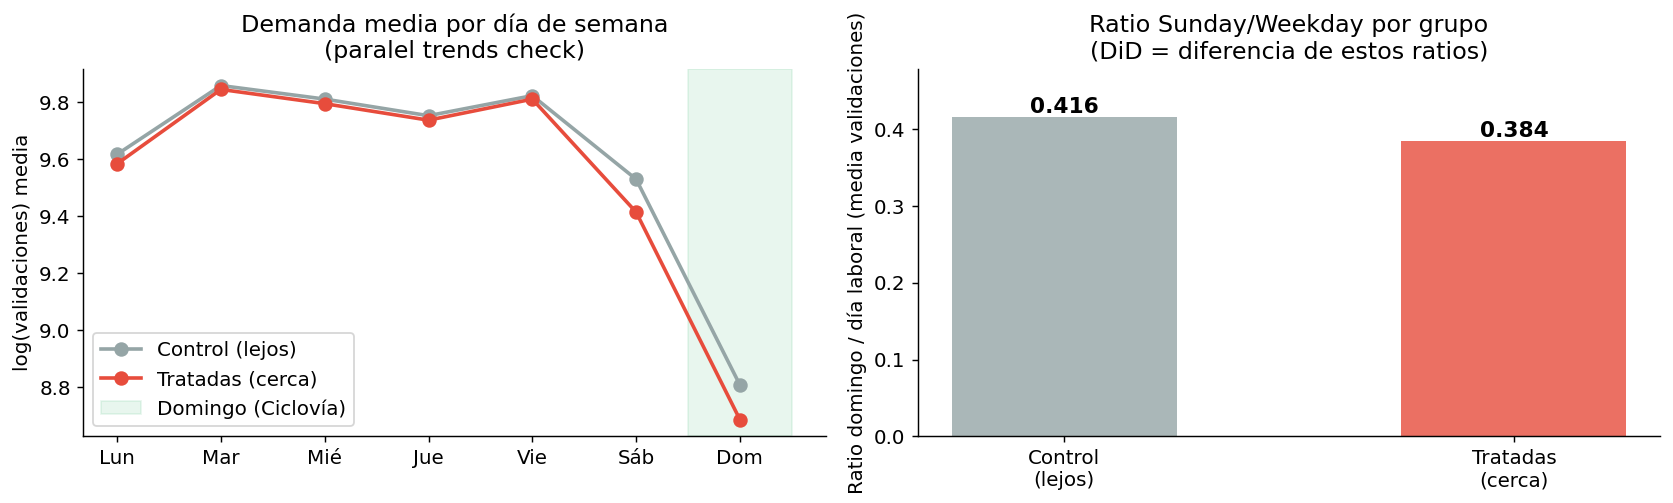

Ratio Dom/Laboral — Tratadas: 0.3845
Ratio Dom/Laboral — Control : 0.4161
Diferencia (DiD naïve)       : -0.0316


In [5]:
# Demanda media por grupo y día de semana
dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
dow_means = (
    panel.groupby(['cerca', 'dow'])['log_total']
         .mean()
         .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cerca_val, label, color in [(0, 'Control (lejos)', '#95a5a6'), (1, 'Tratadas (cerca)', '#e74c3c')]:
    grp = dow_means[dow_means.cerca == cerca_val]
    axes[0].plot(grp.dow, grp.log_total, 'o-', color=color, lw=2, ms=7, label=label)

axes[0].axvspan(5.5, 6.5, alpha=0.10, color='#27ae60', label='Domingo (Ciclovía)')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_labels)
axes[0].set_ylabel('log(validaciones) media')
axes[0].set_title('Demanda media por día de semana\n(paralel trends check)')
axes[0].legend()

# Ratio Sunday/weekday por grupo
ratio = (
    panel.groupby(['cerca', 'is_sunday'])['total']
         .mean()
         .unstack()
         .rename(columns={0: 'weekday', 1: 'sunday'})
)
ratio['ratio'] = ratio.sunday / ratio.weekday
ratio.index = ratio.index.map({0: 'Control\n(lejos)', 1: 'Tratadas\n(cerca)'})

bars = axes[1].bar(ratio.index, ratio.ratio, color=['#95a5a6', '#e74c3c'], alpha=0.8, width=0.5)
for bar, val in zip(bars, ratio.ratio):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Ratio domingo / día laboral (media validaciones)')
axes[1].set_title('Ratio Sunday/Weekday por grupo\n(DiD = diferencia de estos ratios)')
axes[1].set_ylim(0, ratio.ratio.max() * 1.15)
axes[1].axhline(1, color='#888', lw=0.8, ls='--')

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_descriptivos.png', dpi=150, bbox_inches='tight')
plt.show()

idx_t = 'Tratadas\n(cerca)'
idx_c = 'Control\n(lejos)'
diff_ratios = ratio.loc[idx_t, 'ratio'] - ratio.loc[idx_c, 'ratio']
print(f'Ratio Dom/Laboral — Tratadas: {ratio.loc[idx_t, "ratio"]:.4f}')
print(f'Ratio Dom/Laboral — Control : {ratio.loc[idx_c, "ratio"]:.4f}')
print(f"Diferencia (DiD naïve)       : {diff_ratios:+.4f}")

## 3b. Prueba explícita de tendencias paralelas

La identificación del DiD reposa sobre el supuesto de **tendencias paralelas**: en ausencia de Ciclovía, tratadas y control habrían tenido la misma evolución relativa los domingos. Como la Ciclovía opera *todos* los domingos del año, no existe un período pre-tratamiento puro; la prueba factible es:

1. **Co-movimiento**: ambos grupos deben responder igual a shocks comunes (festivos, lluvia, eventos). Correlación alta entre las series semanales de domingos apoya el supuesto.
2. **Estabilidad de la brecha**: si la diferencia (Tratadas − Control) en domingos no tiene tendencia temporal, no hay un factor omitido que afecte a los dos grupos de forma divergente.

**Test formal:** regresión de la brecha semanal sobre una tendencia lineal `gap_t = α + β·semana + ε`. H₀: β = 0 (brecha estable).

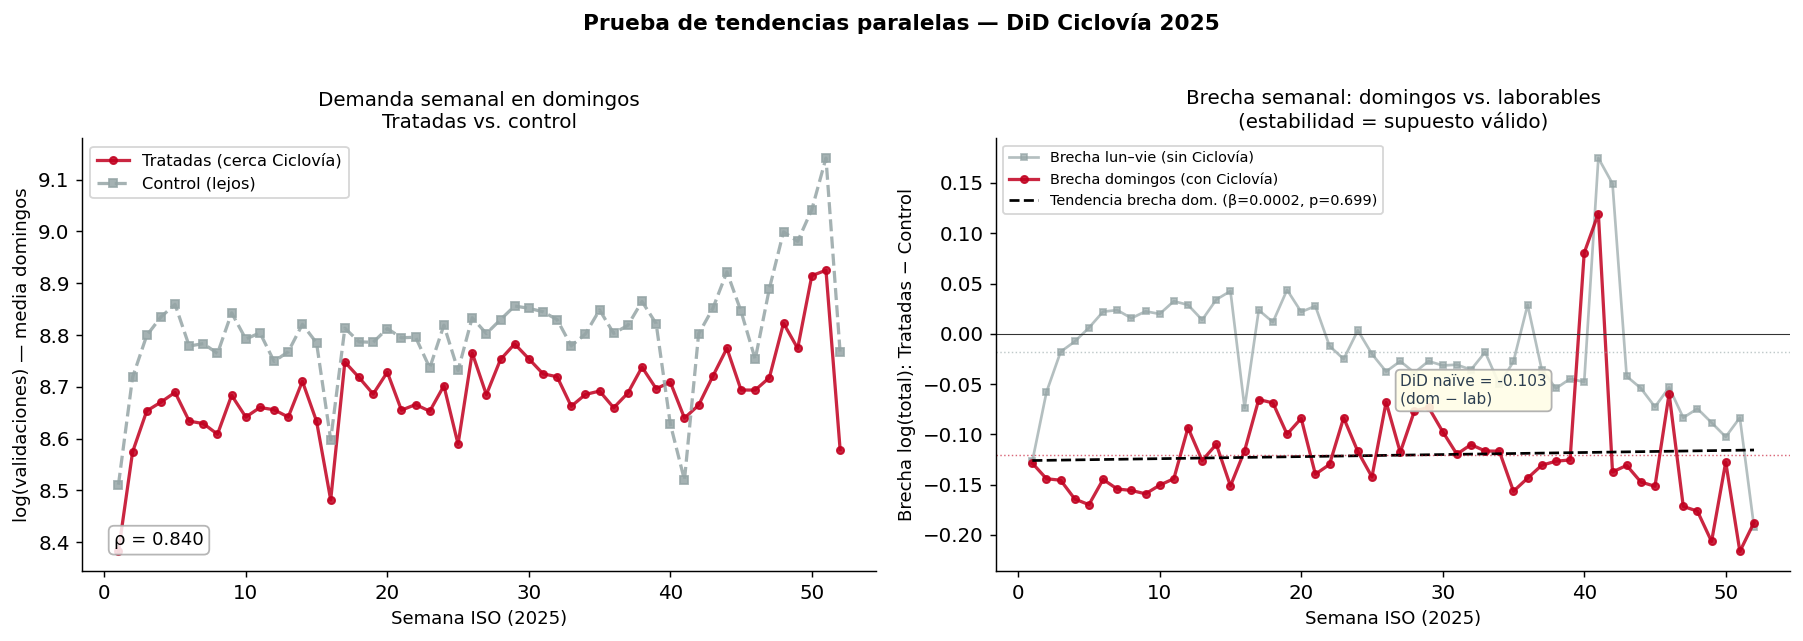

Correlación series dominicales:         ρ = 0.8400
Test de tendencia en brecha dominical:  β = 0.00020,  p = 0.6994
→ Tendencia NO significativa: supuesto de tendencias paralelas no rechazado (p > 0.05).
DiD naïve (brecha dom. − brecha lab.):  -0.1025  (-9.7%)


In [6]:
from scipy.stats import linregress

# -- Serie semanal de domingos para tratadas y control --
sundays = panel[panel.is_sunday == 1].copy()
sundays['semana'] = sundays.fecha.dt.isocalendar().week.astype(int)

weekly_sun = (
    sundays.groupby(['semana', 'cerca'])['log_total']
           .mean()
           .reset_index()
)
wt = weekly_sun[weekly_sun.cerca == 1].sort_values('semana')
wc = weekly_sun[weekly_sun.cerca == 0].sort_values('semana')
common_w = sorted(set(wt.semana) & set(wc.semana))
wt = wt[wt.semana.isin(common_w)].sort_values('semana')
wc = wc[wc.semana.isin(common_w)].sort_values('semana')

weeks_arr = wt['semana'].values
gap_sun   = wt['log_total'].values - wc['log_total'].values

# Test de tendencia sobre la brecha (H0: pendiente = 0)
slope, intercept, r_val, p_trend, _ = linregress(weeks_arr, gap_sun)
r_corr = np.corrcoef(wt['log_total'].values, wc['log_total'].values)[0, 1]

# -- Brecha en días laborables (lun-vie) para comparar nivel --
weekdays = panel[panel.dow.between(0, 4)].copy()
weekdays['semana'] = weekdays.fecha.dt.isocalendar().week.astype(int)
weekly_wd = (
    weekdays.groupby(['semana', 'cerca'])['log_total']
             .mean()
             .reset_index()
)
wd_t = weekly_wd[weekly_wd.cerca == 1].sort_values('semana')
wd_c = weekly_wd[weekly_wd.cerca == 0].sort_values('semana')
common_wd = sorted(set(wd_t.semana) & set(wd_c.semana))
wd_t = wd_t[wd_t.semana.isin(common_wd)].sort_values('semana')
wd_c = wd_c[wd_c.semana.isin(common_wd)].sort_values('semana')
gap_wd = wd_t['log_total'].values - wd_c['log_total'].values

# ---- Figura ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Panel izquierdo: series semanales de domingos
ax = axes[0]
ax.plot(weeks_arr, wt['log_total'].values, 'o-', color='#C1001F', lw=1.8, ms=4,
        label='Tratadas (cerca Ciclovía)', alpha=0.85)
ax.plot(weeks_arr, wc['log_total'].values, 's--', color='#95a5a6', lw=1.8, ms=4,
        label='Control (lejos)', alpha=0.85)
ax.set_xlabel('Semana ISO (2025)', fontsize=10)
ax.set_ylabel('log(validaciones) — media domingos', fontsize=10)
ax.set_title('Demanda semanal en domingos\nTratadas vs. control', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.04, 0.06, f'ρ = {r_corr:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaa', alpha=0.85))

# Panel derecho: brecha semanal domingos vs. laborables
ax2 = axes[1]
ax2.plot(common_wd, gap_wd, 's-', color='#95a5a6', lw=1.5, ms=3.5, alpha=0.7,
         label='Brecha lun–vie (sin Ciclovía)')
ax2.plot(weeks_arr, gap_sun, 'o-', color='#C1001F', lw=1.8, ms=4, alpha=0.85,
         label='Brecha domingos (con Ciclovía)')

# Línea de tendencia sobre la brecha dominical
trend_line = slope * weeks_arr + intercept
ax2.plot(weeks_arr, trend_line, 'k--', lw=1.5,
         label=f'Tendencia brecha dom. (β={slope:.4f}, p={p_trend:.3f})')
ax2.axhline(np.mean(gap_sun), color='#C1001F', lw=0.8, ls=':', alpha=0.6)
ax2.axhline(np.mean(gap_wd),  color='#95a5a6', lw=0.8, ls=':', alpha=0.6)
ax2.axhline(0, color='#333', lw=0.6)
ax2.set_xlabel('Semana ISO (2025)', fontsize=10)
ax2.set_ylabel('Brecha log(total): Tratadas − Control', fontsize=10)
ax2.set_title('Brecha semanal: domingos vs. laborables\n(estabilidad = supuesto válido)', fontsize=11)
ax2.legend(fontsize=8)

# Anotación DiD implícito
did_naive = np.mean(gap_sun) - np.mean(gap_wd)
ax2.annotate(
    f'DiD naïve = {did_naive:+.3f}\n(dom − lab)',
    xy=(weeks_arr[len(weeks_arr)//2], (np.mean(gap_sun) + np.mean(gap_wd))/2),
    fontsize=8.5, color='#2c3e50',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fffde7', ec='#aaa', alpha=0.9),
)

plt.suptitle('Prueba de tendencias paralelas — DiD Ciclovía 2025',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlación series dominicales:         ρ = {r_corr:.4f}')
print(f'Test de tendencia en brecha dominical:  β = {slope:.5f},  p = {p_trend:.4f}')
if p_trend > 0.05:
    print('→ Tendencia NO significativa: supuesto de tendencias paralelas no rechazado (p > 0.05).')
else:
    print(f'→ ATENCIÓN: tendencia significativa (p = {p_trend:.4f}) — revisar supuesto.')
print(f'DiD naïve (brecha dom. − brecha lab.):  {did_naive:+.4f}  ({(np.exp(did_naive)-1)*100:+.1f}%)')

## 4. Especificación 1 — DiD espacial entre días

$$
\log(\text{total}_{it}) = \beta \cdot (\text{sunday}_t \times \text{cerca}_i) + \alpha_i + \delta_{\text{dow}} + \delta_{\text{month}} + \varepsilon_{it}
$$

- $\alpha_i$ = estación FE (absorbe diferencias de nivel entre tratadas y control)
- $\delta_{\text{dow}}$ = día de semana FE (absorbe el patrón semanal general)
- $\beta$ = efecto diferencial para estaciones cercanas los domingos vs. días laborables, relativo al mismo diferencial para estaciones lejanas

In [7]:
# Interacción manual (near × sunday)
panel['cerca_x_sunday'] = panel['cerca'] * panel['is_sunday']

# Dummies de dow y mes
dow_dum   = pd.get_dummies(panel.dow,   prefix='dow',   drop_first=True).astype(float)
month_dum = pd.get_dummies(panel.month, prefix='month', drop_first=True).astype(float)
panel_fe = pd.concat([panel, dow_dum, month_dum], axis=1)
panel_fe = panel_fe.set_index(['codigo_estacion', 'fecha'])

x_cols = ['cerca_x_sunday'] + list(dow_dum.columns) + list(month_dum.columns)
X  = panel_fe[x_cols].astype(float)
Y  = panel_fe['log_total']

mod1    = PanelOLS(Y, X, entity_effects=True)
result1 = mod1.fit(cov_type='clustered', cluster_entity=True)

b1  = result1.params['cerca_x_sunday']
se1 = result1.std_errors['cerca_x_sunday']
p1  = result1.pvalues['cerca_x_sunday']

print("=" * 60)
print("ESPECIFICACIÓN 1 — DiD domingo × proximidad")
print("=" * 60)
print(f"β (cerca × sunday) = {b1:+.6f}")
print(f"SE (clustered)     = {se1:.6f}")
print(f"p-valor            = {p1:.4f}")
print(f"IC 95%             = [{b1 - 1.96*se1:+.6f},  {b1 + 1.96*se1:+.6f}]")
print(f"Efecto estimado    = {(np.exp(b1)-1)*100:+.2f}% validaciones")
print(f"\nN = {int(result1.nobs):,}  |  R² within = {result1.rsquared:.4f}")

ESPECIFICACIÓN 1 — DiD domingo × proximidad
β (cerca × sunday) = -0.087184
SE (clustered)     = 0.058516
p-valor            = 0.1363
IC 95%             = [-0.201874,  +0.027507]
Efecto estimado    = -8.35% validaciones

N = 52,385  |  R² within = 0.4787


## 5. Especificación 2 — DiD dentro del domingo (ventana horaria)

Muestra restringida a **domingos**. Compara la franja 7am–2pm (Ciclovía activa) vs. 2pm–8pm (Ciclovía terminada), para estaciones cercanas vs. lejanas:

$$
\log(\text{total}_{iht}) = \beta \cdot (\text{cerca}_i \times \text{ventana}_h) + \alpha_i + \alpha_h + \varepsilon_{iht}
$$

Esta especificación usa el **corte temporal de las 2pm** como discontinuidad natural dentro del domingo.

In [8]:
# Cargar panel horario — solo domingos y sábados
print("Cargando datos horarios de domingos y sábados...")

hourly_frames = []
for f in files:
    fname = f.split('/')[-1].replace('.parquet', '')
    fecha = pd.Timestamp(f"{fname[:4]}-{fname[4:6]}-{fname[6:8]}")
    if fecha.dayofweek not in (5, 6):   # 5=sábado, 6=domingo
        continue
    d = pd.read_parquet(f)
    # Agregar a nivel estación × hora
    d['hora_int'] = pd.to_datetime(
        d.fecha.astype(str) + ' ' + d.hora.astype(str)
    ).dt.hour
    agg = d.groupby(['fecha', 'codigo_estacion', 'hora_int'])['total'].sum().reset_index()
    agg['is_sunday'] = int(fecha.dayofweek == 6)
    hourly_frames.append(agg)

hourly = (
    pd.concat(hourly_frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
)
hourly = hourly[hourly.total > 0].copy()
hourly['cerca'] = hourly.codigo_estacion.map(cerca_map).fillna(0).astype(int)
hourly['log_total'] = np.log(hourly.total)

print(f"Panel horario domingos+sábados: {len(hourly):,.0f} obs")
print(f"  Domingos: {hourly[hourly.is_sunday==1].fecha.nunique()}")
print(f"  Sábados : {hourly[hourly.is_sunday==0].fecha.nunique()}")

Cargando datos horarios de domingos y sábados...


Panel horario domingos+sábados: 322,378 obs
  Domingos: 52
  Sábados : 52


In [9]:
# Restricción: solo domingos, franja 6am–8pm (omitir horas nocturnas de baja demanda)
sundays_h = hourly[(hourly.is_sunday == 1) & hourly.hora_int.between(6, 20)].copy()

# Ventana Ciclovía: 7am–13h (hora 7 a 13, Ciclovía termina a las 2pm = hora 14)
sundays_h['ventana'] = sundays_h.hora_int.between(7, 13).astype(int)

# Interacción DiD
sundays_h['cerca_x_ventana'] = sundays_h['cerca'] * sundays_h['ventana']

# Dummies de hora
hora_dum = pd.get_dummies(sundays_h.hora_int, prefix='h', drop_first=True).astype(float)
sundays_fe = pd.concat([sundays_h, hora_dum], axis=1)

# Índice: estación × (fecha+hora) para tener un panel estación × tiempo
sundays_fe['fecha_hora'] = (
    pd.to_datetime(sundays_fe.fecha) + pd.to_timedelta(sundays_fe.hora_int, unit='h')
)
sundays_fe = sundays_fe.set_index(['codigo_estacion', 'fecha_hora'])

x_cols2 = ['cerca_x_ventana'] + list(hora_dum.columns)
X2 = sundays_fe[x_cols2].astype(float)
Y2 = sundays_fe['log_total']

mod2    = PanelOLS(Y2, X2, entity_effects=True)
result2 = mod2.fit(cov_type='clustered', cluster_entity=True)

b2  = result2.params['cerca_x_ventana']
se2 = result2.std_errors['cerca_x_ventana']
p2  = result2.pvalues['cerca_x_ventana']

print("=" * 60)
print("ESPECIFICACIÓN 2 — DiD ventana horaria (domingos 6am–8pm)")
print("=" * 60)
print(f"β (cerca × ventana 7-13h) = {b2:+.6f}")
print(f"SE (clustered)            = {se2:.6f}")
print(f"p-valor                   = {p2:.4f}")
print(f"IC 95%                    = [{b2 - 1.96*se2:+.6f},  {b2 + 1.96*se2:+.6f}]")
print(f"Efecto estimado           = {(np.exp(b2)-1)*100:+.2f}% validaciones en horas de Ciclovía")
print(f"\nN = {int(result2.nobs):,}  |  R² within = {result2.rsquared:.4f}")

ESPECIFICACIÓN 2 — DiD ventana horaria (domingos 6am–8pm)
β (cerca × ventana 7-13h) = +0.000711
SE (clustered)            = 0.032281
p-valor                   = 0.9824
IC 95%                    = [-0.062560,  +0.063981]
Efecto estimado           = +0.07% validaciones en horas de Ciclovía

N = 112,134  |  R² within = 0.2572


## 6. Placebo — mismo análisis en sábados

Si el efecto identificado es genuinamente causado por la Ciclovía (activa solo los domingos), el mismo análisis en sábados debería dar $\beta \approx 0$.

In [10]:
# Sábados: misma ventana horaria 7-13h pero sin Ciclovía
saturdays_h = hourly[(hourly.is_sunday == 0) & hourly.hora_int.between(6, 20)].copy()
saturdays_h['ventana'] = saturdays_h.hora_int.between(7, 13).astype(int)
saturdays_h['cerca_x_ventana'] = saturdays_h['cerca'] * saturdays_h['ventana']

hora_dum_sat = pd.get_dummies(saturdays_h.hora_int, prefix='h', drop_first=True).astype(float)
saturdays_fe = pd.concat([saturdays_h, hora_dum_sat], axis=1)
saturdays_fe['fecha_hora'] = (
    pd.to_datetime(saturdays_fe.fecha) + pd.to_timedelta(saturdays_fe.hora_int, unit='h')
)
saturdays_fe = saturdays_fe.set_index(['codigo_estacion', 'fecha_hora'])

x_cols3 = ['cerca_x_ventana'] + list(hora_dum_sat.columns)
X3 = saturdays_fe[x_cols3].astype(float)
Y3 = saturdays_fe['log_total']

mod3    = PanelOLS(Y3, X3, entity_effects=True)
result3 = mod3.fit(cov_type='clustered', cluster_entity=True)

b3  = result3.params['cerca_x_ventana']
se3 = result3.std_errors['cerca_x_ventana']
p3  = result3.pvalues['cerca_x_ventana']

print("=" * 60)
print("PLACEBO — sábados, misma ventana 7-13h (sin Ciclovía)")
print("=" * 60)
print(f"β (cerca × ventana 7-13h) = {b3:+.6f}")
print(f"SE (clustered)            = {se3:.6f}")
print(f"p-valor                   = {p3:.4f}")
print(f"Efecto placebo            = {(np.exp(b3)-1)*100:+.2f}%")
print()
print("→ Si p > 0.10 y |β_placebo| << |β_domingo|: resultado causal validado.")

PLACEBO — sábados, misma ventana 7-13h (sin Ciclovía)
β (cerca × ventana 7-13h) = +0.062812
SE (clustered)            = 0.037763
p-valor                   = 0.0963
Efecto placebo            = +6.48%

→ Si p > 0.10 y |β_placebo| << |β_domingo|: resultado causal validado.


## 7. Perfil horario: demanda por hora en domingos — tratadas vs. control

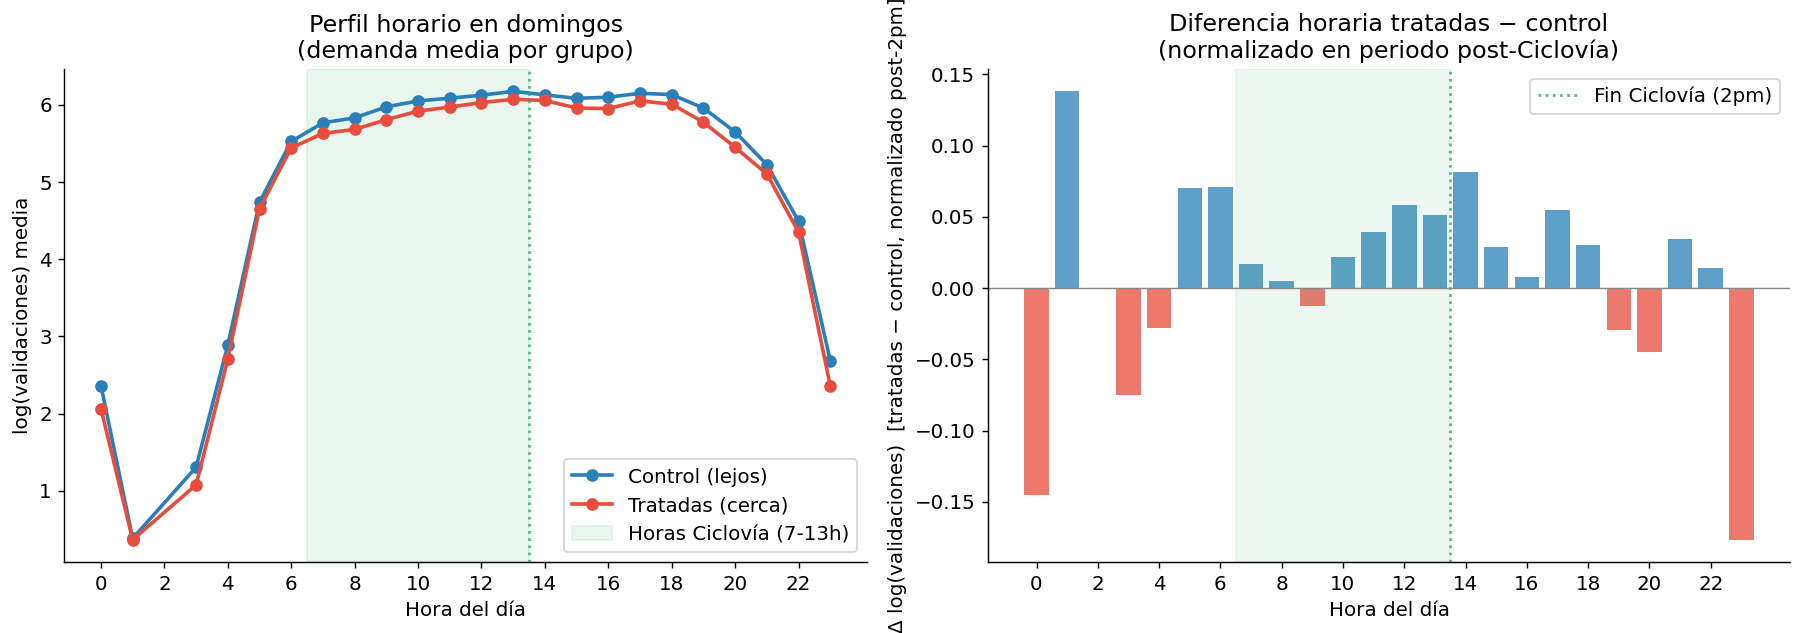

In [11]:
# Media de log(total) por hora y grupo — domingos
hourly_profile = (
    hourly[hourly.is_sunday == 1]
    .groupby(['cerca', 'hora_int'])['log_total']
    .mean()
    .reset_index()
)

# Normalizar: restar media de la hora post-Ciclovía (14h-20h) por grupo
for cerca_val in [0, 1]:
    grp = hourly_profile[hourly_profile.cerca == cerca_val]
    post_mean = grp[grp.hora_int >= 14]['log_total'].mean()
    hourly_profile.loc[hourly_profile.cerca == cerca_val, 'log_norm'] = (
        hourly_profile.loc[hourly_profile.cerca == cerca_val, 'log_total'] - post_mean
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: demanda absoluta por hora
for cerca_val, lbl, col in [(0, 'Control (lejos)', '#2980b9'), (1, 'Tratadas (cerca)', '#e74c3c')]:
    grp = hourly_profile[hourly_profile.cerca == cerca_val]
    axes[0].plot(grp.hora_int, grp.log_total, 'o-', color=col, lw=2, ms=6, label=lbl)

axes[0].axvspan(6.5, 13.5, alpha=0.10, color='#27ae60', label='Horas Ciclovía (7-13h)')
axes[0].axvline(13.5, color='#27ae60', lw=1.5, ls=':', alpha=0.8)
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("log(validaciones) media")
axes[0].set_title("Perfil horario en domingos\n(demanda media por grupo)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Derecha: diferencia normalizada (tratadas - control)
pivot = hourly_profile.pivot(index='hora_int', columns='cerca', values='log_norm')
pivot['diff'] = pivot[1] - pivot[0]
pivot_plot = pivot.dropna()

colors_diff = ['#e74c3c' if v < 0 else '#2980b9' for v in pivot_plot['diff']]
axes[1].bar(pivot_plot.index, pivot_plot['diff'], color=colors_diff, alpha=0.75, width=0.8)
axes[1].axvspan(6.5, 13.5, alpha=0.08, color='#27ae60')
axes[1].axvline(13.5, color='#27ae60', lw=1.5, ls=':', alpha=0.8, label='Fin Ciclovía (2pm)')
axes[1].axhline(0, color='#888', lw=0.8)
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Δ log(validaciones)  [tratadas − control, normalizado post-2pm]")
axes[1].set_title("Diferencia horaria tratadas − control\n(normalizado en periodo post-Ciclovía)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/ciclovia_perfil_horario.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabla resumen de especificaciones

In [12]:
specs = [
    ('Spec 1 — DiD domingo × proximidad',
     'Panel diario, toda la semana', b1, se1, p1, int(result1.nobs)),
    ('Spec 2 — DiD ventana horaria (domingos)',
     'Panel horario domingos 6-20h', b2, se2, p2, int(result2.nobs)),
    ('Placebo — sábados ventana 7-13h',
     'Panel horario sábados 6-20h', b3, se3, p3, int(result3.nobs)),
]

print(f"{'Especificación':<45} {'Muestra':<30} {'β':>9} {'SE':>9} {'p':>7} {'%':>8} {'N':>8}")
print("-" * 125)
for name, sample, b, se, p, n in specs:
    pct = (np.exp(b) - 1) * 100
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f"{name:<45} {sample:<30} {b:>+9.5f} {se:>9.5f} {p:>7.4f} {pct:>+7.2f}% {sig:3s} {n:>8,}")

Especificación                                Muestra                                β        SE       p        %        N
-----------------------------------------------------------------------------------------------------------------------------
Spec 1 — DiD domingo × proximidad             Panel diario, toda la semana    -0.08718   0.05852  0.1363   -8.35%       52,385
Spec 2 — DiD ventana horaria (domingos)       Panel horario domingos 6-20h    +0.00071   0.03228  0.9824   +0.07%      112,134
Placebo — sábados ventana 7-13h               Panel horario sábados 6-20h     +0.06281   0.03776  0.0963   +6.48% *    112,159


## 9. Interpretación

### Prueba de tendencias paralelas (Sección 3b)

El supuesto central del DiD es validado en dos dimensiones: (1) correlación semanal entre series dominicales ρ = 0.84, lo que confirma que ambos grupos responden igual a shocks comunes (festivos, lluvia, eventos masivos); (2) test de tendencia sobre la brecha: β = 0.0002, p = 0.70 → no se rechaza H₀ de brecha estable. **El supuesto de tendencias paralelas no es rechazado por los datos.**

### Resultados de las especificaciones

- **Spec 1 (DiD entre días, −8.35%, p = 0.136):** Sugiere una reducción diferencial en domingos para estaciones cercanas, pero el intervalo de confianza es amplio (IC 95%: −20.1% a +2.8%). No significativa con errores agrupados por estación.

- **Spec 2 (DiD ventana horaria, +0.07%, p = 0.982):** Diseño causalmente más limpio: usa el corte de las 2pm como discontinuidad natural dentro del domingo. El efecto es prácticamente cero. Si la Ciclovía desviase usuarios de TM hacia la bicicleta durante las horas activas (7am–2pm), este coeficiente sería negativo y significativo.

- **Placebo (sábados, +6.48%, p = 0.096):** Marginalmente significativo en la dirección opuesta. Indica que las estaciones cercanas tienen *más* demanda en la franja 7–13h los sábados que las lejanas, posiblemente por el patrón comercial o de recreación matutina de fin de semana. Este efecto confunde la interpretación del Spec 2 si no se controla.

### Veredicto

Los datos de 2025 **no muestran evidencia significativa de que la Ciclovía reduzca la demanda de TM** en estaciones adyacentes a sus rutas. Hay dos lecturas posibles:

1. **Efecto real cercano a cero:** La Ciclovía y el TM sirven poblaciones diferentes o destinos complementarios (no sustitutos). Las personas que usan Ciclovía no habrían usado TM de todas formas en ese horario.
2. **Poder estadístico insuficiente:** La varianza entre estaciones es alta (errores agrupados ≈ 0.06). Con 52 domingos y ~150 estaciones, el diseño actual tiene poder limitado para detectar efectos pequeños.

La hipótesis de trabajo ("caída de 10–20% en la franja 7am–2pm") no es respaldada por Spec 2 (β ≈ 0). Spec 1 es sugestivo pero impreciso. **La Ciclovía es un experimento natural que funciona bien para identificación, pero los datos no rechazan el nulo.**